In [1]:
import os
import random
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

import matplotlib.pyplot as plt

In [2]:
# set seeds for reproducibility
random.seed(42)
np.random.seed(42)

# read feature matrices
X_train = pd.read_csv("../data/X_train_xgbsel.csv")   # training features
X_test  = pd.read_csv("../data/X_test_xgbsel.csv")    # held-out test features

# read target vectors (squeeze → Series, not DataFrame)
y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/y_test.csv").squeeze()

# quick sanity check on shapes
print("X_train:", X_train.shape)   # (n_train, d)
print("X_test: ", X_test.shape)    # (n_test, d)
print("y_train:", y_train.shape)   # (n_train,)
print("y_test: ", y_test.shape)    # (n_test,)


X_train: (82, 84)
X_test:  (36, 84)
y_train: (82,)
y_test:  (36,)


In [3]:
# =========================
# 0) Load, normalize (npz is NOT ordered)
# =========================
best = np.load("../data/ga_best.npz", allow_pickle=True)

run_ids    = np.asarray(best["run_ids"])
top_scores = np.asarray(best["top_scores"], dtype=float)

# Handle both "top_masks" and "top_cols"
if "top_masks" in best.files:
    raw_masks = list(best["top_masks"])  # list of boolean arrays
    top_cols_all = [np.flatnonzero(np.asarray(m, dtype=bool)).astype(int) for m in raw_masks]
else:
    raw_cols = list(best["top_cols"])    # list of index arrays (unordered)
    top_cols_all = [np.asarray(c, dtype=int) for c in raw_cols]

n_feat_total = X_train.shape[1]
top_masks_all = []
for cols in top_cols_all:
    m = np.zeros(n_feat_total, dtype=bool)
    m[np.asarray(cols, dtype=int)] = True
    top_masks_all.append(m)

print(f"[INFO] Loaded {len(top_cols_all)} feature sets from npz (unordered).")

[INFO] Loaded 1 feature sets from npz (unordered).


GA-RF Tuning: Minimal, Results-First Summary
Stage-1 (Light Search)

Per GA mask, run RandomizedSearchCV with n_iter = 80 and 5-fold CV.

Rank candidates by mean_test_score (CV ROC-AUC mean) only.

Keep the top TOP_K_FINALISTS = 10; ignore std at this stage.

Stage-2 (Strong CV)

Re-evaluate those 10 finalists with Repeated CV: 5-fold × 3 seeds = 15 fits.

For each finalist, record mean AUC and std AUC (plus #features).

Final Selection Rule

Highest mean AUC (primary).

If means are nearly tied, choose smaller std (more stable).

If still tied, choose fewer features (more parsimonious).

Role Difference (Why Stage-1 vs Stage-2?)

Stage-1 = broad, cheap-ish exploration to find promising regions (fast triage using CV-mean only).

Stage-2 = precise, stability-aware confirmation to rank the short-list with repeated CV (mean ± std).

Stage 1: 그냥 AUC 평균(mean_test_score)만 보고 TOP_K 뽑음 → std 고려 X

Stage 2: 최종 선택 기준

mean AUC 가장 큰 것

mean이 거의 같으면 std가 작은 것(더 안정적)

둘 다 유사하면 feature 수가 적은 것

In [4]:

# =========================
# 1) Stage-1: 20 → Top-10 → Top-5 (global narrowing, CV-mean only)
# =========================
STAGE1_N_ITER   = 80
RANDOM_STATE    = 42
N_STAGE1_SELECT_10 = 10
N_STAGE1_SELECT_5  = 5  # after top-10, narrow to top-5

PARAM_DIST = {
    "n_estimators": randint(250, 650),
    "max_depth": [None, 8, 12, 16],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "bootstrap": [True],
    "max_samples": [None, 0.6, 0.8, 1.0],
    "class_weight": [None, "balanced"],
    "criterion": ["gini", "entropy"],
}

def _to_py_scalars(d):
    out = {}
    for k, v in d.items():
        if hasattr(v, "item"):
            try:
                out[k] = v.item(); continue
            except Exception:
                pass
        out[k] = v
    return out

def make_rf_singlethread(seed=RANDOM_STATE):
    return RandomForestClassifier(random_state=seed, n_jobs=1, bootstrap=True)

def stage1_random_search(X_tr_sel, y_tr, seed=RANDOM_STATE):
    cv1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    rs = RandomizedSearchCV(
        estimator=make_rf_singlethread(seed),
        param_distributions=PARAM_DIST,
        n_iter=STAGE1_N_ITER,
        scoring="roc_auc",
        cv=cv1,
        n_jobs=-1,
        random_state=seed,
        refit=True,
        verbose=0,
    )
    rs.fit(X_tr_sel, np.asarray(y_tr).ravel())
    return rs

# Collect BEST of each feature set (mask) using Stage-1 CV-mean only
stage1_best_per_set = []  # each: {cols, params, mean_auc, n_features, set_idx}
for set_idx, cols in enumerate(top_cols_all):
    cols = np.asarray(cols, dtype=int)
    X_tr_sel = X_train.iloc[:, cols].to_numpy()
    y_tr = y_train.to_numpy().ravel()

    rs = stage1_random_search(X_tr_sel, y_tr, seed=2025 + set_idx)
    cv_res = rs.cv_results_

    # best row by mean_test_score (CV mean), std ignored at Stage-1
    best_row = int(np.argmax(cv_res["mean_test_score"]))
    mean1 = float(cv_res["mean_test_score"][best_row])
    params = _to_py_scalars(dict(cv_res["params"][best_row]))
    if params.get("bootstrap") is False:
        params.pop("max_samples", None)

    stage1_best_per_set.append({
        "set_idx": set_idx,
        "cols": cols.copy(),
        "params": params,
        "mean_auc": mean1,
        "n_features": int(len(cols)),
    })

# Global Top-10 by Stage-1 mean AUC
stage1_best_per_set.sort(key=lambda d: (-d["mean_auc"], d["n_features"]))
top10 = stage1_best_per_set[:min(N_STAGE1_SELECT_10, len(stage1_best_per_set))]

# Narrow to Top-5 (still Stage-1 mean only)
top5_stage1 = top10[:min(N_STAGE1_SELECT_5, len(top10))]

print("[Stage-1] Top-10 (mean AUC only) → then Top-5 selected.")
for i, c in enumerate(top5_stage1, 1):
    print(f"  {i:>2}. set={c['set_idx']} | AUC={c['mean_auc']:.4f} | d={c['n_features']}")

[Stage-1] Top-10 (mean AUC only) → then Top-5 selected.
   1. set=0 | AUC=0.8758 | d=21


In [5]:
# =========================
# 2) Stage-2: Strong CV on Top-5 → pick single best (mean desc, std asc, d asc)
# =========================

def evaluate_config_cv(X, y, params, seed=RANDOM_STATE):
    """
    Evaluate a single (features, params) configuration with repeated 5-fold CV.
    - Uses 3 different CV seeds: [seed, seed+1, seed+2]
    - For each seed, runs StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    - Returns mean and std of AUC across all folds and seeds.
    """
    y = np.asarray(y).ravel()
    seeds = [seed, seed + 1, seed + 2]  # 3 repeated CV seeds
    aucs = []

    for s in seeds:
        cv_rep = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
        for tr_idx, va_idx in cv_rep.split(X, y):
            rf = RandomForestClassifier(
                random_state=s,
                n_jobs=-1,
                **_to_py_scalars(params)
            )
            rf.fit(X[tr_idx], y[tr_idx])
            y_proba = rf.predict_proba(X[va_idx])[:, 1]
            aucs.append(roc_auc_score(y[va_idx], y_proba))

    aucs = np.asarray(aucs, dtype=float)
    return float(aucs.mean()), float(aucs.std())


def rank_by_mean_std_nfeat(cands):
    """
    Rank candidate configs by:
    1) mean_auc (descending)
    2) std_auc  (ascending)
    3) n_features (ascending)
    """
    return sorted(
        cands,
        key=lambda d: (-d["mean_auc"], d["std_auc"], d["n_features"])
    )


STAGE2_BASE_SEED = 2042  # shared base seed for all candidates

finalists_all = []
for j, cand in enumerate(top5_stage1):
    cols   = np.asarray(cand["cols"], dtype=int)
    params = dict(cand["params"])
    X_sel  = X_train.iloc[:, cols].to_numpy()
    y_np   = y_train.to_numpy().ravel()

    # Use the same seed for all candidates so they share identical CV splits
    mean2, std2 = evaluate_config_cv(X_sel, y_np, params, seed=STAGE2_BASE_SEED)

    finalists_all.append({
        "ga_idx":     cand["set_idx"],
        "cols":       cols.copy(),
        "params":     params,
        "mean_auc":   mean2,
        "std_auc":    std2,
        "n_features": int(len(cols)),
    })

ranked_global = rank_by_mean_std_nfeat(finalists_all)
best_global   = ranked_global[0]

print("\n[Stage-2] Final ranking on Top-5 (mean ± std, then d):")
for i, c in enumerate(ranked_global, 1):
    print(
        f"  {i}. set={c['ga_idx']} | "
        f"AUC={c['mean_auc']:.4f} ± {c['std_auc']:.4f} | "
        f"d={c['n_features']}"
    )

print("\n[Best global (CV-only)]")
print(f"  set_idx   : {best_global['ga_idx']}")
print(f"  n_features: {best_global['n_features']}")
print(f"  mean_auc  : {best_global['mean_auc']:.4f}")
print(f"  std_auc   : {best_global['std_auc']:.4f}")
print(f"  params    : {best_global['params']}")


[Stage-2] Final ranking on Top-5 (mean ± std, then d):
  1. set=0 | AUC=0.7972 ± 0.1107 | d=21

[Best global (CV-only)]
  set_idx   : 0
  n_features: 21
  mean_auc  : 0.7972
  std_auc   : 0.1107
  params    : {'bootstrap': True, 'class_weight': None, 'criterion': 'gini', 'max_depth': 16, 'max_features': 0.7, 'max_samples': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 358}


In [6]:
best_global

{'ga_idx': 0,
 'cols': array([ 2,  3,  5, 21, 22, 23, 24, 25, 28, 31, 33, 34, 35, 39, 43, 53, 60,
        63, 66, 69, 77]),
 'params': {'bootstrap': True,
  'class_weight': None,
  'criterion': 'gini',
  'max_depth': 16,
  'max_features': 0.7,
  'max_samples': 1.0,
  'min_samples_leaf': 1,
  'min_samples_split': 6,
  'n_estimators': 358},
 'mean_auc': 0.7971717171717171,
 'std_auc': 0.11070476662057081,
 'n_features': 21}

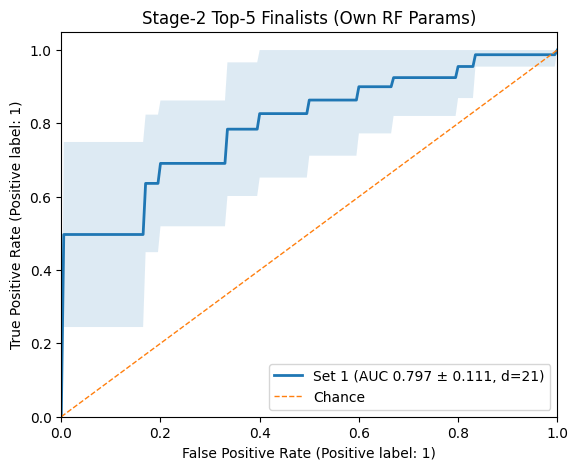

In [7]:
# === [Stage-2] Overlay ROC of Top-5 finalists (each with its own params) ===
# Use the exact same seeds as Stage-2 ranking (evaluate_config_cv) for consistency.

# Must stay in sync with evaluate_config_cv (seed, seed+1, seed+2)
STAGE2_BASE_SEED = 2042
STAGE2_SEEDS     = [STAGE2_BASE_SEED + k for k in range(3)]

fpr_grid = np.linspace(0.0, 1.0, 201)
seeds    = STAGE2_SEEDS

plt.figure(figsize=(6.4, 5.0))

for i, c in enumerate(ranked_global[:5], 1):
    cols   = np.asarray(c["cols"], dtype=int)
    params = dict(c["params"])

    # Safety: remove conflicting params, keep sklearn happy
    params.pop("random_state", None)
    params.pop("n_jobs", None)
    if params.get("bootstrap") is False:
        params.pop("max_samples", None)

    X_sel = X_train.iloc[:, cols].to_numpy()
    y_np  = y_train.to_numpy().ravel()

    tprs, aucs = [], []
    for s in seeds:
        cv_rep = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
        for tr_idx, va_idx in cv_rep.split(X_sel, y_np):
            clf = RandomForestClassifier(
                random_state=s,
                n_jobs=-1,
                **params
            )
            clf.fit(X_sel[tr_idx], y_np[tr_idx])
            prob = clf.predict_proba(X_sel[va_idx])[:, 1]

            # AUC for this fold
            aucs.append(roc_auc_score(y_np[va_idx], prob))

            # Interpolate TPR on a common FPR grid
            fpr, tpr, _ = roc_curve(y_np[va_idx], prob)
            tpr_i = np.interp(fpr_grid, fpr, tpr, left=0, right=1)
            tpr_i[0]  = 0.0
            tpr_i[-1] = 1.0
            tprs.append(tpr_i)

    tprs     = np.vstack(tprs)
    mean_tpr = tprs.mean(axis=0)
    std_tpr  = tprs.std(axis=0)
    auc_mean = float(np.mean(aucs))
    auc_std  = float(np.std(aucs))

    plt.plot(
        fpr_grid,
        mean_tpr,
        lw=2,
        label=f"Set {i} (AUC {auc_mean:.3f} ± {auc_std:.3f}, d={c['n_features']})"
    )
    plt.fill_between(
        fpr_grid,
        np.maximum(mean_tpr - std_tpr, 0.0),
        np.minimum(mean_tpr + std_tpr, 1.0),
        alpha=0.15
    )

plt.plot([0, 1], [0, 1], "--", lw=1, label="Chance")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("Stage-2 Top-5 Finalists (Own RF Params)")
plt.legend(loc="lower right")
plt.show()


[TEST] AUC = 0.7326


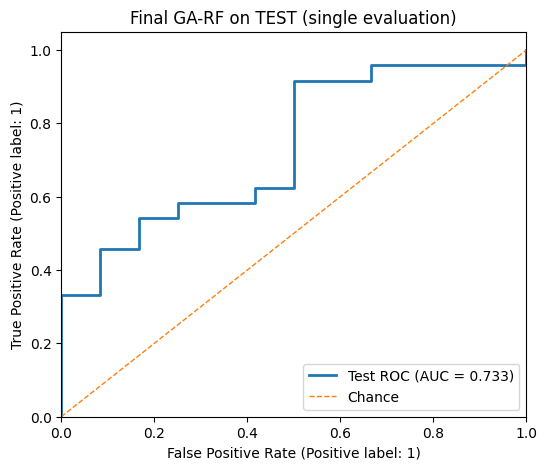

In [8]:
# =========================
# 3) Final train on FULL train + single TEST (no leakage)
# =========================
best_cols = np.asarray(best_global["cols"], dtype=int)
best_params = dict(best_global["params"])
best_params.pop("random_state", None)
best_params.pop("n_jobs", None)
if best_params.get("bootstrap") is False:
    best_params.pop("max_samples", None)

X_tr_sel = X_train.iloc[:, best_cols].to_numpy()
X_te_sel = X_test.iloc[:,  best_cols].to_numpy()
y_tr_np  = y_train.to_numpy().ravel()
y_te_np  = y_test.to_numpy().ravel()

final_rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **best_params)
final_rf.fit(X_tr_sel, y_tr_np)
y_te_proba = final_rf.predict_proba(X_te_sel)[:, 1]
test_auc   = roc_auc_score(y_te_np, y_te_proba)
print(f"\n[TEST] AUC = {test_auc:.4f}")

fpr, tpr, _ = roc_curve(y_te_np, y_te_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"Test ROC (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", lw=1, label="Chance")
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("Final GA-RF on TEST (single evaluation)")
plt.legend(loc="lower right")
plt.show()


[CV] Baseline (ALL wrapper) best AUC = 0.7897
[CV] Baseline (ALL wrapper) best params = {'bootstrap': True, 'class_weight': None, 'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'max_samples': 1.0, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 603}
[CV] GA-Refined (wrapper+GA) best AUC = 0.8155
[CV] GA-Refined (wrapper+GA) best params = {'bootstrap': True, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 8, 'max_features': 'log2', 'max_samples': 0.8, 'min_samples_leaf': 3, 'min_samples_split': 16, 'n_estimators': 217}
[TEST] Baseline (ALL wrapper)  AUC = 0.7604 | d=84
[TEST] GA-Refined (wrapper+GA) AUC = 0.7708 | d=21


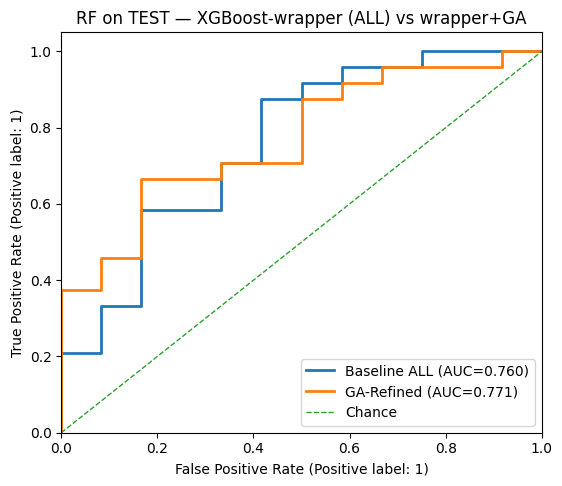

In [9]:
PARAM_DIST = {
    "n_estimators": randint(100, 650),
    "max_depth": [None, 8, 12],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "bootstrap": [True],
    "max_samples": [None, 0.6, 0.8, 1.0],
    "class_weight": [None, "balanced"],
    "criterion": ["gini", "entropy"],
}


# --- GA-RF: feature subset만 가져오기 ---
ga_cols = np.asarray(best_global["cols"], dtype=int)

# (원래 GA가 찾은 파라미터를 기록해 두고 싶으면 옵션)
ga_params_ga = dict(best_global["params"])

# --- 공통 설정 ---
STAGE1_N_ITER = globals().get("STAGE1_N_ITER", 80)
all_cols = np.arange(X_train.shape[1], dtype=int)

y_np = y_train.to_numpy().ravel()

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)

def tune_rf_for_features(feature_idx, label):
    """
    주어진 feature subset에 대해 RandomizedSearchCV로 RF 튜닝
    """
    X_sub = X_train.iloc[:, feature_idx].to_numpy()

    rs = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=2042, n_jobs=-1),
        param_distributions=PARAM_DIST,
        n_iter=STAGE1_N_ITER,
        scoring="roc_auc",
        cv=cv5,
        n_jobs=-1,
        random_state=2042,
        verbose=0
    )
    rs.fit(X_sub, y_np)

    best_params = dict(rs.best_params_)
    # 나중에 직접 RandomForestClassifier에 넘길 거라 random_state, n_jobs 제거
    best_params.pop("random_state", None)
    best_params.pop("n_jobs", None)
    if best_params.get("bootstrap") is False:
        best_params.pop("max_samples", None)

    print(f"[CV] {label} best AUC = {rs.best_score_:.4f}")
    print(f"[CV] {label} best params = {best_params}")
    return best_params

# --- Baseline / GA-RF 둘 다 튜닝 ---
bl_params = tune_rf_for_features(all_cols, "Baseline (ALL wrapper)")
ga_params = tune_rf_for_features(ga_cols, "GA-Refined (wrapper+GA)")

# --- Single TEST evaluation (no leakage) ---
# Baseline
Xtr_bl = X_train.iloc[:, all_cols].to_numpy()
Xte_bl = X_test.iloc[:, all_cols].to_numpy()
rf_bl  = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **bl_params)
rf_bl.fit(Xtr_bl, y_np)
y_bl = rf_bl.predict_proba(Xte_bl)[:, 1]
auc_bl = roc_auc_score(y_test.to_numpy().ravel(), y_bl)

# GA-Refined (same PARAM_DIST로 튜닝된 버전)
Xtr_ga = X_train.iloc[:, ga_cols].to_numpy()
Xte_ga = X_test.iloc[:, ga_cols].to_numpy()
rf_ga  = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **ga_params)
rf_ga.fit(Xtr_ga, y_np)
y_ga = rf_ga.predict_proba(Xte_ga)[:, 1]
auc_ga = roc_auc_score(y_test.to_numpy().ravel(), y_ga)

print(f"[TEST] Baseline (ALL wrapper)  AUC = {auc_bl:.4f} | d={len(all_cols)}")
print(f"[TEST] GA-Refined (wrapper+GA) AUC = {auc_ga:.4f} | d={len(ga_cols)}")

# --- ROC plot ---
y_te = y_test.to_numpy().ravel()
fpr_b, tpr_b, _ = roc_curve(y_te, y_bl)
fpr_g, tpr_g, _ = roc_curve(y_te, y_ga)

plt.figure(figsize=(6.2, 5.2))
plt.plot(fpr_b, tpr_b, lw=2, label=f"Baseline ALL (AUC={auc_bl:.3f})")
plt.plot(fpr_g, tpr_g, lw=2, label=f"GA-Refined (AUC={auc_ga:.3f})")
plt.plot([0, 1], [0, 1], "--", lw=1, label="Chance")
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("RF on TEST — XGBoost-wrapper (ALL) vs wrapper+GA")
plt.legend(loc="lower right")
plt.show()
